In [1]:
%load_ext autoreload
%autoreload 2

from SRC.pairs_trading import PairsBacktest
from SRC.data_loader import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns



In [11]:
tickers = ['BTC-USD', 'ETH-USD', 'XRP-USD', 'LTC-USD', 'BCH-USD']
years = 1

In [12]:
# testing yield curve data
loader = DataLoader(years)

curve = loader.usyields


In [13]:
curve

,Repo,One_Month_US,Three_Month_US,Six_Month_US,One_Year_US,Two_Year_US,Three_year_US,Five_Year_US,Ten_Year_US,Twenty_Year_US,Thirty_Year_US
2025-06-30,4.33,4.28,4.41,4.29,3.96,3.72,3.68,3.79,4.24,4.79,4.78
2025-07-01,4.33,4.32,4.40,4.29,3.98,3.78,3.75,3.84,4.26,4.79,4.78
2025-07-02,4.33,4.33,4.41,4.28,3.99,3.78,3.77,3.87,4.30,4.84,4.82
2025-07-03,4.33,4.35,4.42,4.34,4.07,3.88,3.84,3.94,4.35,4.87,4.86
2025-07-04,4.33,4.35,4.42,4.34,4.07,3.88,3.84,3.94,4.35,4.87,4.86
...,...,...,...,...,...,...,...,...,...,...,...
2026-06-21,3.63,3.69,3.83,3.92,4.00,4.19,4.19,4.23,4.46,4.91,4.90
2026-06-22,3.63,3.66,3.85,3.98,4.04,4.24,4.25,4.29,4.51,4.97,4.95
2026-06-23,3.63,3.65,3.85,3.96,4.01,4.16,4.22,4.27,4.50,4.96,4.94
2026-06-24,3.63,3.66,3.85,3.95,3.99,4.11,4.15,4.17,4.41,4.87,4.86


In [8]:
%%capture
# Initialize the backtester
backtester = PairsBacktest(tickers, years, lookback_window=20, entry_z=2)

results = backtester.compute_metrics()


AttributeError: 'PairsBacktest' object has no attribute 'market_data'

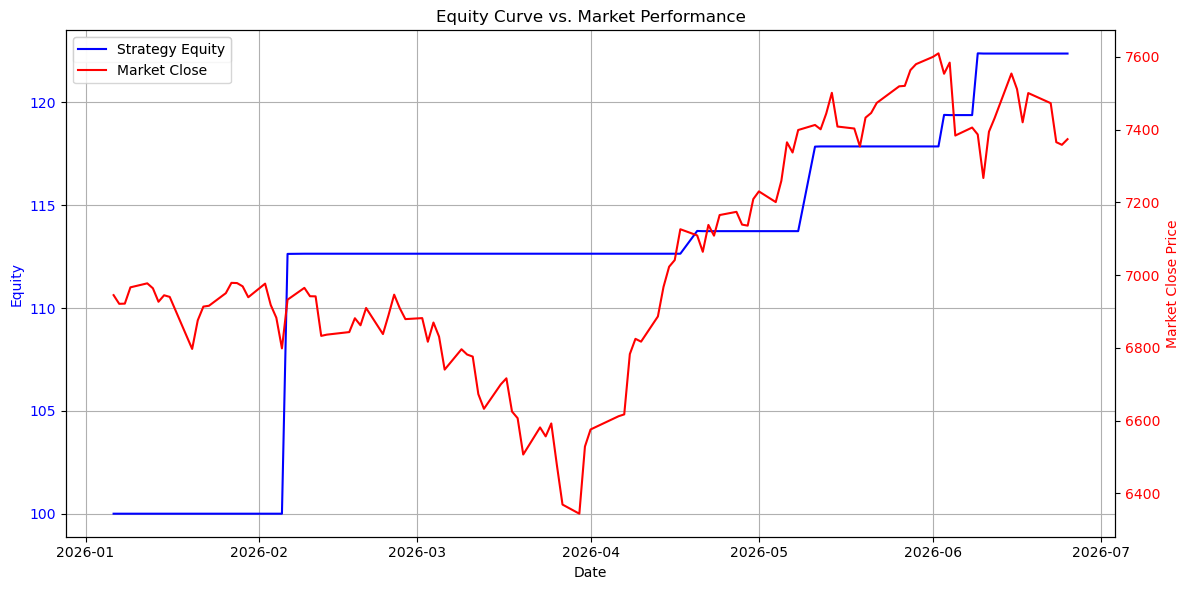

The tickers with the highest correlation, and the ones used in the pairs-trading strategy were LTC-USD and XRP-USD. This strategy used a z-score level of 2.
             Metric       Value
0      Sharpe Ratio     2.14194
1             Alpha   47.55357%
2      Total Return      22.38%
3      Max Drawdown      -0.01%
4        Start Date  2026-01-06
5          End Date  2026-06-25
6  Starting Capital     $100.00
7    Ending Capital     $122.38
8    Capital Gained      $22.38
9      Total Trades           5


In [ ]:
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot Equity Curve on primary y-axis
sns.lineplot(x=backtester.data.index, y=backtester.data['Equity'], ax=ax1, color='blue', label='Strategy Equity')
ax1.set_xlabel('Date')
ax1.set_ylabel('Equity', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.grid(True)

# Create a second y-axis for Market Data
ax2 = ax1.twinx()
sns.lineplot(x=backtester.market_data.index, y=backtester.market_data['Close'].squeeze(), ax=ax2, color='red', label='Market Close')
ax2.set_ylabel('Market Close Price', color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Equity Curve vs. Market Performance')

# Add legends for both axes
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper left')

plt.tight_layout()
plt.show()

print(f"The tickers with the highest correlation, and the ones used in the pairs-trading strategy were {results1[0]} and {results1[1]}. This strategy used a z-score level of {backtester.entry_z}.")
print(results)